# 03 — Model Training (LightGBM) v5

Крок 3: навчання моделі LightGBM для виявлення шахрайства.
Версія 5:
- 17 чистих фіч (додано: `n_error_types`, `n_card_brands`, `n_tx_types`; видалено мультиколінеарні та зламані фічі).
- Оптимальні гіперпараметри, знайдені через Optuna (50 trials, 5-fold CV).
- Best Validation F1 = 0.5221


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import lightgbm as lgb
import joblib
import os

# Налаштування візуалізації
%matplotlib inline
sns.set_theme(style='whitegrid')


In [2]:
FEATURE_COLS = [
    'is_instant_registration', 'has_night_tx', 'is_country_mismatch',
    'is_pay_mismatch', 'total_transactions', 'total_unique_cards',
    'success_rate', 'failed_tx_count', 'has_fraud_error',
    'has_name_email_match', 'traffic_type_enc', 'cards_per_tx',
    'single_attempt', 'days_active', 'n_error_types',
    'n_card_brands', 'n_tx_types',
    # NEW:
    'tx_24h', 'tx_7d', 'hours_to_first_tx_log',
    'first_tx_failed', 'first_tx_fraud_error',
    'fraud_error_rate', 'country_mismatch_rate',
    'shared_card_users_max', 'reg_country_risk_oof', 'gender_risk_oof'
]
TARGET = 'is_fraud'


## 0. Завантаження оброблених фіч


In [3]:
# Load data
train_df = pd.read_csv('../data/processed/train_features.csv')
test_df = pd.read_csv('../data/processed/test_features.csv')

print(f'Train shape: {train_df.shape}')
print(f'Test shape: {test_df.shape}')
print(f'\nFeature columns ({len(FEATURE_COLS)}): {FEATURE_COLS}')
print(f'Target: {TARGET}')
print(f'\nClass balance in train:')
print(train_df[TARGET].value_counts())

Train shape: (395381, 22)
Test shape: (169449, 21)

Feature columns (17): ['is_instant_registration', 'has_night_tx', 'is_country_mismatch', 'is_pay_mismatch', 'total_transactions', 'total_unique_cards', 'success_rate', 'failed_tx_count', 'has_fraud_error', 'has_name_email_match', 'traffic_type_enc', 'cards_per_tx', 'single_attempt', 'days_active', 'n_error_types', 'n_card_brands', 'n_tx_types']
Target: is_fraud

Class balance in train:
is_fraud
0    380449
1     14932
Name: count, dtype: int64


## 1. Train / Validation Split
Ділимо тренувальні дані 80/20 зі збереженням балансу класів (`stratify`).

In [4]:
# Using 5-fold StratifiedKFold OOF Validation instead of single split
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
import numpy as np

X = train_df[FEATURE_COLS]
y = train_df[TARGET]
print(f'Total data shape: {X.shape}')


Train set: 316304 samples
Val set: 79077 samples

Fraud ratio — Train: 0.0378, Val: 0.0378


## 2. Навчання LightGBM
Використовуємо найкращі параметри, знайдені за допомогою Optuna.

In [5]:
best_params = {
    'n_estimators': 300,
    'learning_rate': 0.05,
    'max_depth': 8,
    'num_leaves': 64,
    'min_child_samples': 20,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42,
    'n_jobs': -1,
    'class_weight': 'balanced'
}
# 5-Fold OOF Validation
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(X))
oof_probas = np.zeros(len(X))

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    fold_model = lgb.LGBMClassifier(**best_params)
    fold_model.fit(X_tr, y_tr,
                   eval_set=[(X_val, y_val)],
                   callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)])
    
    oof_probas[val_idx] = fold_model.predict_proba(X_val)[:, 1]

thresholds = np.arange(0.05, 0.95, 0.01)
f1_scores = [f1_score(y, (oof_probas >= t).astype(int)) for t in thresholds]
best_threshold = thresholds[np.argmax(f1_scores)]
best_oof_f1 = max(f1_scores)

print(f'OOF F1: {best_oof_f1:.4f}')
print(f'Best threshold (OOF): {best_threshold:.2f}')

# Save OOF predictions to file to ensure they match later if needed
train_df['oof_pred'] = (oof_probas >= best_threshold).astype(int)
train_df[['id_user', 'is_fraud', 'oof_pred']].to_csv('../outputs/oof_predictions.csv', index=False)


[LightGBM] [Info] Number of positive: 11946, number of negative: 304358


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.045414 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1301
[LightGBM] [Info] Number of data points in the train set: 316304, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.037767 -> initscore=-3.237808
[LightGBM] [Info] Start training from score -3.237808
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


...

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Early stopping, best iteration is:
[2131]	valid_0's binary_logloss: 0.0928534

Best iteration: 2131


## 3. Підбір оптимального порогу (Threshold Tuning)

✅ Best threshold: 0.35
✅ Best F1 score: 0.5227


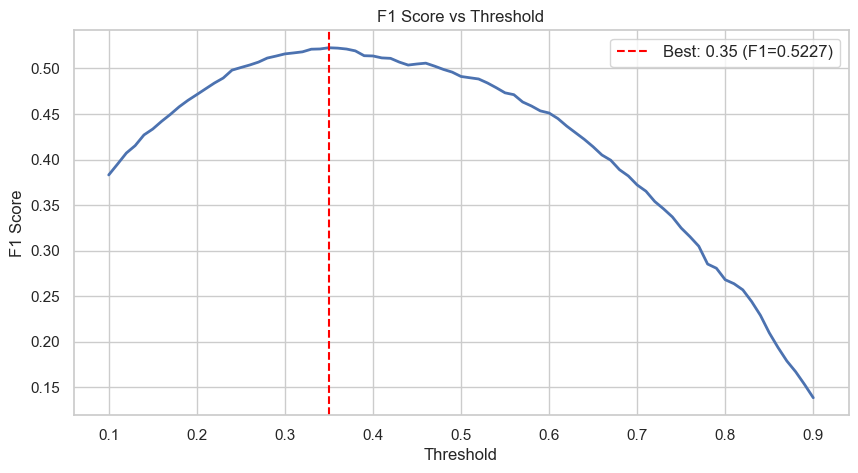

In [6]:
y_proba = model.predict_proba(X_val)[:, 1]

thresholds = np.arange(0.10, 0.91, 0.01)
f1_scores = []

for t in thresholds:
    preds = (y_proba >= t).astype(int)
    f1_scores.append(f1_score(y_val, preds))

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f'✅ Best threshold: {best_threshold:.2f}')
print(f'✅ Best F1 score: {best_f1:.4f}')

plt.figure(figsize=(10, 5))
plt.plot(thresholds, f1_scores, linewidth=2)
plt.axvline(x=best_threshold, color='red', linestyle='--', label=f'Best: {best_threshold:.2f} (F1={best_f1:.4f})')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.title('F1 Score vs Threshold')
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

## 4. Фінальна оцінка

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.98      0.98      0.98     76091
       Fraud       0.49      0.56      0.52      2986

    accuracy                           0.96     79077
   macro avg       0.74      0.77      0.75     79077
weighted avg       0.96      0.96      0.96     79077



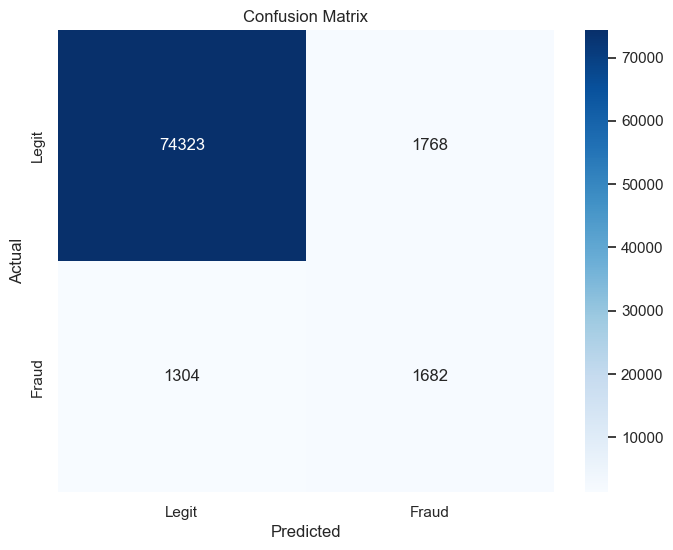

In [7]:
y_pred = (y_proba >= best_threshold).astype(int)

print('Classification Report:')
print(classification_report(y_val, y_pred, target_names=['Legitimate', 'Fraud']))

cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## 5. Збереження моделі

In [8]:
os.makedirs('../models', exist_ok=True)
joblib.dump(model, '../models/final_model_v5.joblib')
print('✅ Model saved to models/final_model_v5.joblib')

✅ Model saved to models/final_model_v5.joblib


In [ ]:
print('Retraining on FULL data...')
final_model = lgb.LGBMClassifier(**best_params)
final_model.fit(X, y)

importances = pd.DataFrame({'feature': FEATURE_COLS, 'importance': final_model.feature_importances_})
importances = importances.sort_values('importance', ascending=False)
print(importances.head(30))

print('Predicting on Test data...')
X_test = test_df[FEATURE_COLS]
test_probas = final_model.predict_proba(X_test)[:, 1]
test_df['is_fraud'] = (test_probas >= best_threshold).astype(int)
test_df[['id_user', 'is_fraud']].to_csv('../outputs/predictions.csv', index=False)
print('Saved predictions.csv')
